**Análisis de Indicadores políticos, económicos y de seguridad para predecir el riesgo de un conflicto**

Abstracto con motivación y audiencia
El análisis de este conjunto de datos está motivado por la necesidad de comprender y anticipar la escalada de conflictos en un entorno global cada vez más interconectado y volátil. Al integrar indicadores geopolíticos, económicos, militares y sociales a lo largo del tiempo, el dataset permite identificar patrones tempranos, dinámicas no lineales y señales de alerta que preceden a episodios de inestabilidad o conflicto significativo dentro de los próximos 6 meses. Analizar estos datos facilita la construcción de sistemas de alerta temprana más realistas, la evaluación comparativa de modelos predictivos y la generación de explicaciones transparentes que apoyen la toma de decisiones informada bajo incertidumbre.

La audiencia que se beneficia de este análisis incluye investigadores académicos, científicos de datos, analistas de riesgo, responsables de políticas públicas, organizaciones internacionales y equipos de seguridad y defensa. Para ellos, el dataset ofrece una base sólida para exploración de datos, modelado temporal, ingeniería de características y explicabilidad, con aplicaciones prácticas en prevención de conflictos, evaluación de riesgos geopolíticos y diseño de estrategias de mitigación basadas en evidencia.

Preguntas hipótesis que debemos de resolver


Resumen de metadata
Se utilizara el dataset de la url https://www.kaggle.com/datasets/muhammadhussnain09/global-geopolitical-conflict-dataset-20202025 el cual tiene 26 columnas con 14 columnas decimales, 8 columnas enteras, 3 columnas de cadenas y una columna de fecha. El archivo tiene 1320 filas (registros)
Las diferentes columnas son:
1. Country (cadena): Nombre del país. Identificador principal para las observaciones.
2. Region (cadena): Región geográfica del país (por ejemplo, Asia Oriental, Oriente Medio).
3. Month (fecha): Mes de observación (formato AAAA-MM). Representa el orden temporal de los modelos con enfoque temporal.
4. political_stability_index (decimal): Puntuación de estabilidad política al estilo del Banco Mundial (−2,5 = muy inestable, +2,5 = muy estable).
5. gdp_growth_pct (decimal): Tasa de crecimiento mensual del PIB (%) — refleja el desempeño económico.
6. inflation_rate (decimal): Tasa de inflación mensual (%) - una inflación más alta indica estrés económico.
7. unemployment_rate (decimal): Porcentaje de población desempleada (indicador socioeconómico).
8. food_price_index (decimal): Índice compuesto de costos de alimentos - mide el estrés social potencial.
9. energy_dependency_pct (decimal): Porcentaje de energía importada - una alta dependencia puede aumentar el riesgo geopolítico.
10. military_expenditure_pct_gdp (decimal): Gasto militar como % del PIB - valores más altos pueden indicar militarización.
11. arms_imports_index (decimal): Medida proxy de las importaciones de armas - un nivel más alto significa una mayor adquisición de armas.
12. border_disputes_count (entera): Número de disputas territoriales/fronterizas en curso - un número mayor puede incrementar la probabilidad de conflicto.
13. refugee_outflow_thousands (decimal): Número de personas que abandonan el país debido a conflictos, persecución o inestabilidad (en miles).
14. sanctions_active (entera): 1 = sanciones internacionales activas contra el país; 0 = ninguna.
15. media_freedom_score (decimal): Índice de libertad de prensa (cuanto más alto, más libres son los medios). Inexistente en algunos regímenes autoritarios.
16. protest_events_last_3m (entera): Número de eventos de protesta en los últimos 3 meses - refleja malestar civil.
17. cyber_attack_incidents (entera): Número de ciberataques denunciados cuyo origen o destino es el país.

18. last_conflict_year (entera): Año del último gran conflicto en el país. Ayuda a modelar el riesgo histórico.
19. trade_dependency_rival_pct (decimal): Porcentaje del comercio que depende de países rivales u hostiles - vulnerabilidad económica.
20. foreign_troops_present (entera): 1 = fuerzas militares extranjeras estacionadas en el país; 0 = ninguna
21. election_cycle (entera): Indicador binario u ordinal de próximas elecciones (0 = no en periodo electoral).
22. regime_type (cadena): Sistema político - democracia, autoritario o híbrido.
23. social_media_sentiment (decimal): Puntuación de sentimiento agregado de las redes sociales (−1 = negativo, +1 = positivo).
24. rolling_protest_avg_6m (decimal): Característica derivada - promedio móvil de seis meses de protestas. Captura la tendencia del malestar.
25. instability_score (decimal): Índice compuesto diseñado que combina factores políticos, económicos, militares y sociales. Cuanto más alto, más inestable.
26. conflict_escalation_6m (entera): Variable objetivo: 1 = alto riesgo de escalada del conflicto en los próximos 6 meses, 0 = estable/riesgo bajo.


Preguntas hipótesis que queremos responde

1.	¿Hay  multicolinealidad entre las variables cuantitativas?

2.	¿Cuáles son las características más importantes para poder predecir la escalación de un conflicto?

3.	¿Afecta el régimen político el hecho de que pueda haber escalación de un conflicto?

4.	¿Afecta la región geografica el hecho de que pueda haber escalación de un conflicto?

5.	¿Se puede construir un modelo predictivo con buena capacidad de anticipación?


Primero procederemos a cargar la base de datos

In [20]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import numpy as np

df = pd.read_csv("geopolitical_conflict_risk_dataset.csv")
print("First 5 records:", df.head())

First 5 records:   country         region    month  political_stability_index  gdp_growth_pct  \
0     USA  North America  2020-01                   0.496714        6.737638   
1     USA  North America  2020-02                  -1.150994        4.467635   
2     USA  North America  2020-03                  -0.460639       -0.030766   
3     USA  North America  2020-04                   0.326845        0.155373   
4     USA  North America  2020-05                   0.293059        0.755706   

   inflation_rate  unemployment_rate  food_price_index  energy_dependency_pct  \
0        5.308678           9.069739        108.263140              60.851201   
1        7.878490           1.116625        125.221590              10.806598   
2       11.285611           8.446705        145.774988              68.625602   
3        5.594405           7.331570         85.482074              44.383874   
4       10.483152           0.405036        111.397987              65.015718   

   military_exp

In [23]:
y = df["conflict_escalation_6m"]
y

,conflict_escalation_6m
0,0
1,1
2,1
3,0
4,0
...,...
1315,0
1316,1
1317,1
1318,0


In [24]:
X = df.drop(columns=["conflict_escalation_6m","month"])
X

,country,region,political_stability_index,gdp_growth_pct,inflation_rate,unemployment_rate,food_price_index,energy_dependency_pct,military_expenditure_pct_gdp,arms_imports_index,...,protest_events_last_3m,cyber_attack_incidents,last_conflict_year,trade_dependency_rival_pct,foreign_troops_present,election_cycle,regime_type,social_media_sentiment,rolling_protest_avg_6m,instability_score
0,USA,North America,0.496714,6.737638,5.308678,9.069739,108.263140,60.851201,2.536582,28.356756,...,3,7,2018,22.210790,1,0,Democracy,-0.907099,2.144414,52.436131
1,USA,North America,-1.150994,4.467635,7.878490,1.116625,125.221590,10.806598,1.671814,44.921531,...,8,5,0,48.252741,0,0,Democracy,-0.457302,9.763522,98.474060
2,USA,North America,-0.460639,-0.030766,11.285611,8.446705,145.774988,68.625602,2.160782,32.269691,...,4,8,2018,31.608400,1,0,Hybrid,0.122487,6.199294,80.755509
3,USA,North America,0.326845,0.155373,5.594405,7.331570,85.482074,44.383874,2.940183,64.029344,...,4,9,2021,47.428411,0,0,Hybrid,0.389570,4.038001,58.176382
4,USA,North America,0.293059,0.755706,10.483152,0.405036,111.397987,65.015718,2.672375,18.460049,...,2,9,2018,17.123555,1,0,Hybrid,-0.663418,1.264349,60.718597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,Brazil,South America,0.535554,4.197241,9.628542,6.851433,101.555807,27.401595,3.661433,0.030908,...,5,5,2018,21.274994,1,0,Hybrid,0.477862,7.869193,60.843167
1316,Brazil,South America,-1.104443,6.209100,7.190500,12.649995,164.874466,71.802412,3.466271,4.192860,...,7,10,0,10.741928,1,0,Authoritarian,-0.834223,7.587282,94.717452
1317,Brazil,South America,-0.602517,3.802182,1.798553,1.496936,118.909163,43.288349,2.345307,52.469426,...,15,10,2022,16.395473,0,0,Authoritarian,-0.829882,15.876647,94.208596
1318,Brazil,South America,-0.459532,1.875219,1.570659,3.547652,166.114588,74.081743,2.187812,55.125785,...,6,11,2014,26.032190,1,0,Hybrid,-0.859598,2.315756,73.075431


In [25]:
X.columns

Index(['country', 'region', 'political_stability_index', 'gdp_growth_pct',
       'inflation_rate', 'unemployment_rate', 'food_price_index',
       'energy_dependency_pct', 'military_expenditure_pct_gdp',
       'arms_imports_index', 'border_disputes_count',
       'refugee_outflow_thousands', 'sanctions_active', 'media_freedom_score',
       'protest_events_last_3m', 'cyber_attack_incidents',
       'last_conflict_year', 'trade_dependency_rival_pct',
       'foreign_troops_present', 'election_cycle', 'regime_type',
       'social_media_sentiment', 'rolling_protest_avg_6m',
       'instability_score'],
      dtype='object')

crearemos una variable X_transform donde usaremos variables dummy para poder hacer modelos de machine learning y poder evaluar que variables tienen colinealidad con otras. Se quitara la primera columna para evitar multicolinealidad

In [26]:
X_transform = pd.get_dummies(df.drop(columns=["conflict_escalation_6m","month"]), columns=['country', "region", "regime_type"], drop_first=True)

In [27]:
X_transform

,political_stability_index,gdp_growth_pct,inflation_rate,unemployment_rate,food_price_index,energy_dependency_pct,military_expenditure_pct_gdp,arms_imports_index,border_disputes_count,refugee_outflow_thousands,...,country_USA,country_Ukraine,region_Eastern Europe,region_Middle East,region_North America,region_South America,region_South Asia,region_Western Europe,regime_type_Democracy,regime_type_Hybrid
0,0.496714,6.737638,5.308678,9.069739,108.263140,60.851201,2.536582,28.356756,3,52.666619,...,True,False,False,False,True,False,False,False,True,False
1,-1.150994,4.467635,7.878490,1.116625,125.221590,10.806598,1.671814,44.921531,1,76.236598,...,True,False,False,False,True,False,False,False,True,False
2,-0.460639,-0.030766,11.285611,8.446705,145.774988,68.625602,2.160782,32.269691,0,130.978395,...,True,False,False,False,True,False,False,False,False,True
3,0.326845,0.155373,5.594405,7.331570,85.482074,44.383874,2.940183,64.029344,4,158.423899,...,True,False,False,False,True,False,False,False,False,True
4,0.293059,0.755706,10.483152,0.405036,111.397987,65.015718,2.672375,18.460049,5,19.204378,...,True,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,0.535554,4.197241,9.628542,6.851433,101.555807,27.401595,3.661433,0.030908,3,132.881990,...,False,False,False,False,False,True,False,False,False,True
1316,-1.104443,6.209100,7.190500,12.649995,164.874466,71.802412,3.466271,4.192860,0,50.471048,...,False,False,False,False,False,True,False,False,False,False
1317,-0.602517,3.802182,1.798553,1.496936,118.909163,43.288349,2.345307,52.469426,5,195.547389,...,False,False,False,False,False,True,False,False,False,False
1318,-0.459532,1.875219,1.570659,3.547652,166.114588,74.081743,2.187812,55.125785,2,33.380370,...,False,False,False,False,False,True,False,False,False,True


In [28]:
X_transform = X_transform.replace({True: 1, False: 0})


/tmp/ipython-input-1785301484.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_transform = X_transform.replace({True: 1, False: 0})


In [29]:
X_transform

,political_stability_index,gdp_growth_pct,inflation_rate,unemployment_rate,food_price_index,energy_dependency_pct,military_expenditure_pct_gdp,arms_imports_index,border_disputes_count,refugee_outflow_thousands,...,country_USA,country_Ukraine,region_Eastern Europe,region_Middle East,region_North America,region_South America,region_South Asia,region_Western Europe,regime_type_Democracy,regime_type_Hybrid
0,0.496714,6.737638,5.308678,9.069739,108.263140,60.851201,2.536582,28.356756,3,52.666619,...,1,0,0,0,1,0,0,0,1,0
1,-1.150994,4.467635,7.878490,1.116625,125.221590,10.806598,1.671814,44.921531,1,76.236598,...,1,0,0,0,1,0,0,0,1,0
2,-0.460639,-0.030766,11.285611,8.446705,145.774988,68.625602,2.160782,32.269691,0,130.978395,...,1,0,0,0,1,0,0,0,0,1
3,0.326845,0.155373,5.594405,7.331570,85.482074,44.383874,2.940183,64.029344,4,158.423899,...,1,0,0,0,1,0,0,0,0,1
4,0.293059,0.755706,10.483152,0.405036,111.397987,65.015718,2.672375,18.460049,5,19.204378,...,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,0.535554,4.197241,9.628542,6.851433,101.555807,27.401595,3.661433,0.030908,3,132.881990,...,0,0,0,0,0,1,0,0,0,1
1316,-1.104443,6.209100,7.190500,12.649995,164.874466,71.802412,3.466271,4.192860,0,50.471048,...,0,0,0,0,0,1,0,0,0,0
1317,-0.602517,3.802182,1.798553,1.496936,118.909163,43.288349,2.345307,52.469426,5,195.547389,...,0,0,0,0,0,1,0,0,0,0
1318,-0.459532,1.875219,1.570659,3.547652,166.114588,74.081743,2.187812,55.125785,2,33.380370,...,0,0,0,0,0,1,0,0,0,1


In [30]:
#Multicolinealidad sin dummies (solo variables cuantitativas)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_cuant = X.drop(columns=['country', "region", "regime_type"])

# Asegúrate de que todo sea numérico
X_cuant = X_cuant.astype(float)

vif_data = pd.DataFrame()
vif_data["feature"] = X_cuant.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_cuant.values, i)
    for i in range(X_cuant.shape[1])
]

print(vif_data)


                         feature         VIF
0      political_stability_index   13.728870
1                 gdp_growth_pct    1.006897
2                 inflation_rate    7.408167
3              unemployment_rate    1.011178
4               food_price_index    1.011855
5          energy_dependency_pct    1.020553
6   military_expenditure_pct_gdp    1.010441
7             arms_imports_index    1.016111
8          border_disputes_count    1.006982
9      refugee_outflow_thousands    1.013757
10              sanctions_active    1.973088
11           media_freedom_score    1.009291
12        protest_events_last_3m   23.417751
13        cyber_attack_incidents    1.008315
14            last_conflict_year    5.484482
15    trade_dependency_rival_pct    1.012572
16        foreign_troops_present    1.016689
17                election_cycle         NaN
18        social_media_sentiment    1.017157
19        rolling_protest_avg_6m    4.346306
20             instability_score  175.507654


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


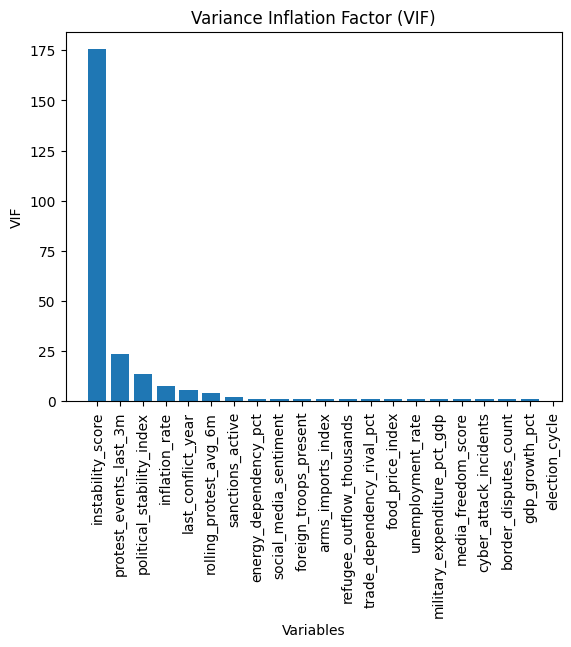

In [31]:
import matplotlib.pyplot as plt

# Ordenar de mayor a menor VIF
vif_data_sorted = vif_data.sort_values(by="VIF", ascending=False)

plt.figure()
plt.bar(vif_data_sorted["feature"], vif_data_sorted["VIF"])

plt.xticks(rotation=90)
plt.xlabel("Variables")
plt.ylabel("VIF")
plt.title("Variance Inflation Factor (VIF)")

plt.show()


Todos los valores con Variance Inflation Factor menores a 5 se puede decir que no tienen problemas con multicolinearidad

In [32]:
print(vif_data_sorted)

                         feature         VIF
20             instability_score  175.507654
12        protest_events_last_3m   23.417751
0      political_stability_index   13.728870
2                 inflation_rate    7.408167
14            last_conflict_year    5.484482
19        rolling_protest_avg_6m    4.346306
10              sanctions_active    1.973088
5          energy_dependency_pct    1.020553
18        social_media_sentiment    1.017157
16        foreign_troops_present    1.016689
7             arms_imports_index    1.016111
9      refugee_outflow_thousands    1.013757
15    trade_dependency_rival_pct    1.012572
4               food_price_index    1.011855
3              unemployment_rate    1.011178
6   military_expenditure_pct_gdp    1.010441
11           media_freedom_score    1.009291
13        cyber_attack_incidents    1.008315
8          border_disputes_count    1.006982
1                 gdp_growth_pct    1.006897
17                election_cycle         NaN


Respuesta de Hipotesis 1

Las variables con problemas de multicolinearidad son instability_score, protest_events_last_3m, political_stability_index, inflation_rate y last_conflict_year siendo la respuesta a la ** hipotesis 1**

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_transform, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000
)

model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

Respuesta de hipotesis 2

Para la hipotesis 2 de que variables son mas importantes y la hipotesis 5 sobre que se puede construir un modelo de clasificacion

In [35]:
coef_df = pd.DataFrame({
    "feature": X_transform.columns,
    "coef": model.coef_[0]
})

coef_df = coef_df[coef_df["coef"] != 0]
coef_df = coef_df.sort_values(by="coef", key=abs, ascending=False)

print(coef_df)

                         feature      coef
20             instability_score  3.167434
0      political_stability_index -0.727571
2                 inflation_rate  0.231358
29           country_North Korea  0.213464
10              sanctions_active  0.197319
43          region_South America  0.178905
47            regime_type_Hybrid -0.168881
18        social_media_sentiment -0.140783
46         regime_type_Democracy -0.123040
13        cyber_attack_incidents -0.119809
3              unemployment_rate  0.115712
22                country_France -0.115469
7             arms_imports_index -0.107108
21                 country_China  0.101728
4               food_price_index  0.101539
15    trade_dependency_rival_pct -0.089153
32                country_Russia  0.079665
35                country_Taiwan -0.066007
37                    country_UK -0.050419
25                  country_Iran -0.050200
24                 country_India  0.047316
9      refugee_outflow_thousands  0.046384
28         

In [36]:
len(coef_df)

36

**Para la hipotesis 2** se tenian al principio 48 columnas una vez hecho los dummies, de los cuales se descartaron 12 y solo quedaron los 36 que quedan arriba

Respuesta de hipotesis 5

In [38]:
model.score(X_test_scaled, y_test)

0.9204545454545454

Se construyo el modelo de regression logistica con una exactitud del 92.045%, lo cual muestra que **la hipotesis 5 es correcta**

Respuesta de hipotesis 3

In [39]:
regime_escalation = (
    df.groupby("regime_type")["conflict_escalation_6m"]
    .mean()
    .reset_index()
)


In [40]:
regime_escalation

,regime_type,conflict_escalation_6m
0,Authoritarian,0.340796
1,Democracy,0.303030
2,Hybrid,0.302632


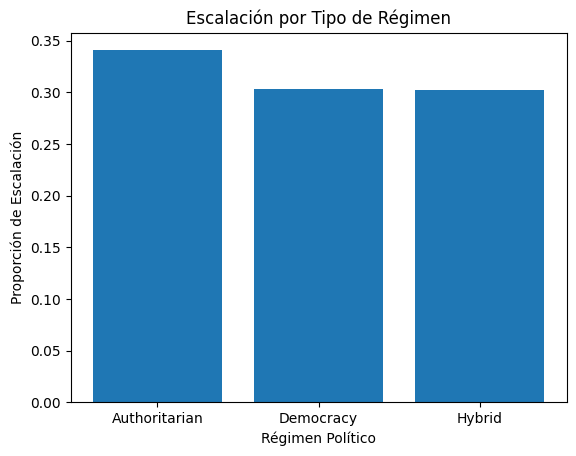

In [41]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(regime_escalation["regime_type"],
        regime_escalation["conflict_escalation_6m"])

plt.xlabel("Régimen Político")
plt.ylabel("Proporción de Escalación")
plt.title("Escalación por Tipo de Régimen")
plt.show()


Debido a que son casi iguales las proporciones de conflicto en los 3 tipos de regimen podemos decir que no afecta el tipo de regimen

Respuesta de hipotesis 4

In [42]:
region_escalation = (
    df.groupby("region")["conflict_escalation_6m"]
    .mean()
    .reset_index()
)


In [43]:
region_escalation

,region,conflict_escalation_6m
0,East Asia,0.342424
1,Eastern Europe,0.318182
2,Middle East,0.363636
3,North America,0.257576
4,South America,0.227273
5,South Asia,0.310606
6,Western Europe,0.284848


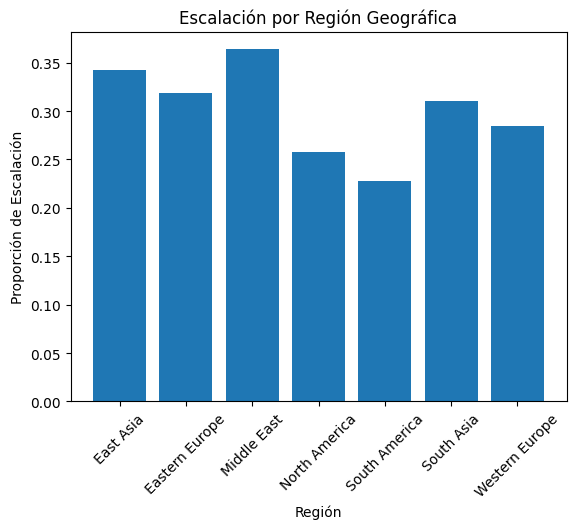

In [44]:
plt.figure()
plt.bar(region_escalation["region"],
        region_escalation["conflict_escalation_6m"])

plt.xticks(rotation=45)
plt.xlabel("Región")
plt.ylabel("Proporción de Escalación")
plt.title("Escalación por Región Geográfica")
plt.show()


In [45]:
tabla = pd.crosstab(df["region"], df["conflict_escalation_6m"])
print(tabla)

conflict_escalation_6m    0    1
region                          
East Asia               217  113
Eastern Europe          135   63
Middle East             126   72
North America            49   17
South America            51   15
South Asia               91   41
Western Europe          236   94


In [46]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 8.101178193436729
p-value: 0.2307840812586372


Aunque hay diferencias entre las zonas geograficas el p valor indica que no hay una diferencia significativa entre regiones gegograficas. Aunque se puede ver que en America es donde menos escalacion de conflicto hay y el este medio donde mas escalacion de conflicto hay